## Grupo
- Caroline Morales Leitão RA00338380
- Bruna Silva Costa RA00370616
- Vinícius Budoya monteiro RA00338338

# Aula 6 - Hackeando a IA: ataques adversariais

Sua equipe baixa imagens reais de placas da internet, treina uma CNN em segredo e entrega somente o arquivo `.pt`. A equipe adversaria precisa adivinhar que imagens voce usou, baixar um arsenal proprio e enganar sua rede com o FGSM. Depois, voce defende o proprio modelo.

Leia `DESAFIO-HACKEANDO-A-IA.md`. Arduino ou ESP32 na demonstracao vale bonus no placar.

## 1. Montar o dataset secreto (baixando imagens)

Cada equipe escolhe e baixa as proprias imagens reais. Sugestao de fontes livres: Wikimedia Commons, Unsplash, Pexels.

Regras do dataset:

- pasta `placas_dataset/` com uma subpasta por classe: `PARAR`, `PROIBIDO` e `ATENCAO`;
- no minimo 40 imagens por classe;
- variar paises, angulos, distancias e iluminacao;
- registrar origem e licenca de cada arquivo em `placas_dataset/CREDITOS.csv`;
- **o dataset e secreto**: nao mostre as pastas a equipe adversaria.

Formato do `CREDITOS.csv`:

```text
arquivo,fonte,licenca
001.jpg,Wikimedia Commons (Stop sign us.jpg),CC BY-SA
```

Total: 120 imagens | forma: (120, 3, 40, 40)
  PARAR: 40 imagens
  PROIBIDO: 40 imagens
  ATENCAO: 40 imagens


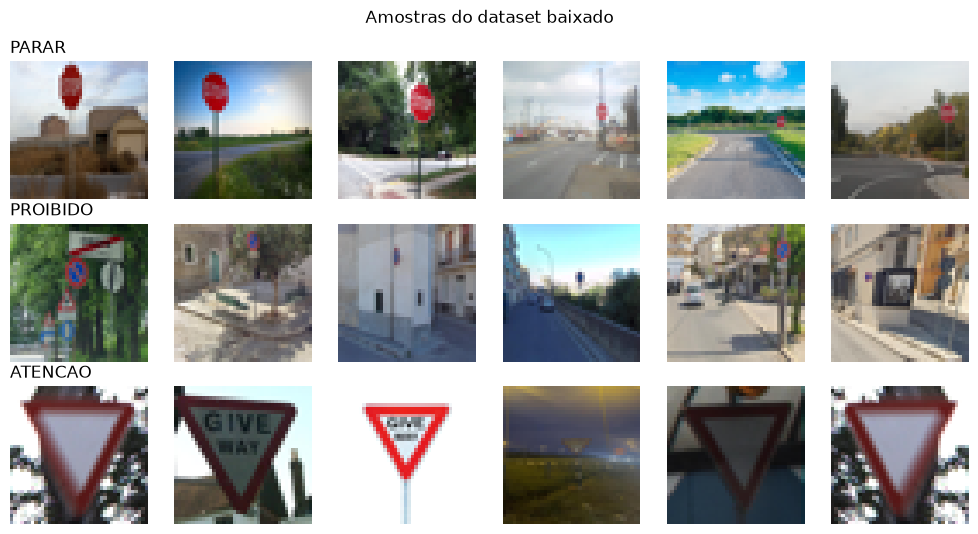

In [1]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

RANDOM_STATE = 64
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.set_num_threads(2)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CLASSES = ["PARAR", "PROIBIDO", "ATENCAO"]
IMG = 40
PASTA = Path("placas_dataset")

def carregar_dataset(PASTA):
    imagens, rotulos = [], []
    for classe, nome in enumerate(CLASSES):
        arquivos = sorted(p for p in (PASTA / nome).glob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png"})
        for caminho in arquivos:
            imagem = Image.open(caminho).convert("RGB").resize((IMG, IMG))
            imagens.append(np.asarray(imagem, dtype=np.float32) / 255.0)
            rotulos.append(classe)
    return np.stack(imagens).transpose(0, 3, 1, 2), np.array(rotulos)

X_todos, y_todos = carregar_dataset(PASTA)
print(f"Total: {len(X_todos)} imagens | forma: {X_todos.shape}")
for classe, nome in enumerate(CLASSES):
    print(f"  {nome}: {(y_todos == classe).sum()} imagens")

fig, axes = plt.subplots(3, 6, figsize=(10, 5.4))
for classe in range(3):
    exemplos = X_todos[y_todos == classe][:6]
    for coluna in range(6):
        axes[classe, coluna].imshow(exemplos[coluna].transpose(1, 2, 0))
        axes[classe, coluna].axis("off")
        if coluna == 0:
            axes[classe, coluna].set_title(CLASSES[classe], loc="left")
plt.suptitle("Amostras do dataset baixado")
plt.tight_layout()
plt.show()

## 2. Separar e treinar a CNN

O treino e o teste saem do seu dataset secreto. Para deixar o treino mais rico com poucas fotos, repetimos cada imagem com pequenos deslocamentos e variacoes de brilho (aumento de dados).

Exigencia do torneio: acuracia minima de 95% no seu proprio teste antes de entregar o modelo.

In [2]:
def aumentar(imagens, rotulos, copias=4, desloc=3):
    rng = np.random.default_rng(RANDOM_STATE)
    saida_x, saida_y = [], []
    for imagem, rotulo in zip(imagens, rotulos):
        for _ in range(copias):
            variacao = np.roll(imagem, rng.integers(-desloc, desloc + 1), axis=(1, 2))
            variacao = np.clip(variacao * rng.uniform(0.8, 1.2), 0, 1)
            saida_x.append(variacao)
            saida_y.append(rotulo)
    return np.array(saida_x), np.array(saida_y)

idx = np.arange(len(X_todos))
treino_idx, teste_idx = train_test_split(idx, test_size=0.25, random_state=RANDOM_STATE, stratify=y_todos)
X_aug, y_aug = aumentar(X_todos[treino_idx], y_todos[treino_idx])
X_teste_arr, y_teste_arr = X_todos[teste_idx], y_todos[teste_idx]

X_treino = torch.tensor(X_aug, dtype=torch.float32)
y_treino = torch.tensor(y_aug, dtype=torch.long)
X_teste = torch.tensor(X_teste_arr, dtype=torch.float32)
y_teste = torch.tensor(y_teste_arr, dtype=torch.long)
loader_treino = DataLoader(TensorDataset(X_treino, y_treino), batch_size=32, shuffle=True)
loader_teste = DataLoader(TensorDataset(X_teste, y_teste), batch_size=64)
print(f"Treino (aumentado): {len(X_treino)} | Teste: {len(X_teste)} | Dispositivo: {device}")

Treino (aumentado): 360 | Teste: 30 | Dispositivo: cpu


In [3]:
class PlacaCNN(nn.Module):
    def __init__(self, filtros1=16, filtros2=32, img_size=IMG):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, filtros1, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(filtros1, filtros2, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        # Calcula a dimensão automaticamente (evita o erro 3200 vs 8192)
        dim = img_size // 4
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(filtros2 * dim * dim, 64), nn.ReLU(), nn.Linear(64, 3),
        )

    def forward(self, imagem):
        return self.classifier(self.features(imagem))

def avaliar(modelo, loader):
    modelo.eval()
    previsoes, rotulos = [], []
    with torch.no_grad():
        for imagens, rotulo in loader:
            saida = modelo(imagens.to(device)).argmax(dim=1).cpu().numpy()
            previsoes.extend(saida)
            rotulos.extend(rotulo.numpy())
    return np.array(previsoes), np.array(rotulos)

def treinar(modelo, loader, epocas=12, taxa=0.001):
    otimizador = torch.optim.Adam(modelo.parameters(), lr=taxa)
    criterio = nn.CrossEntropyLoss()
    for epoca in range(epocas):
        modelo.train()
        perda_total = 0.0
        for imagens, rotulos in loader:
            otimizador.zero_grad()
            perda = criterio(modelo(imagens.to(device)), rotulos.to(device))
            perda.backward()
            otimizador.step()
            perda_total += perda.item()
        previsoes, rotulos = avaliar(modelo, loader_teste)
        print(f"Epoca {epoca + 1:02d} | perda {perda_total / len(loader):.4f} | acuracia {accuracy_score(rotulos, previsoes):.2%}")

modelo = PlacaCNN().to(device)
treinar(modelo, loader_treino, epocas=12)
print(f"Parametros: {sum(p.numel() for p in modelo.parameters()):,}")

Epoca 01 | perda 1.0901 | acuracia 36.67%
Epoca 02 | perda 0.9912 | acuracia 70.00%
Epoca 03 | perda 0.8338 | acuracia 86.67%
Epoca 04 | perda 0.6696 | acuracia 83.33%
Epoca 05 | perda 0.5596 | acuracia 83.33%
Epoca 06 | perda 0.4551 | acuracia 80.00%
Epoca 07 | perda 0.3815 | acuracia 86.67%
Epoca 08 | perda 0.3222 | acuracia 86.67%
Epoca 09 | perda 0.2574 | acuracia 86.67%
Epoca 10 | perda 0.2039 | acuracia 90.00%
Epoca 11 | perda 0.1472 | acuracia 90.00%
Epoca 12 | perda 0.1216 | acuracia 86.67%
Parametros: 210,147


Acuracia no teste: 86.67%


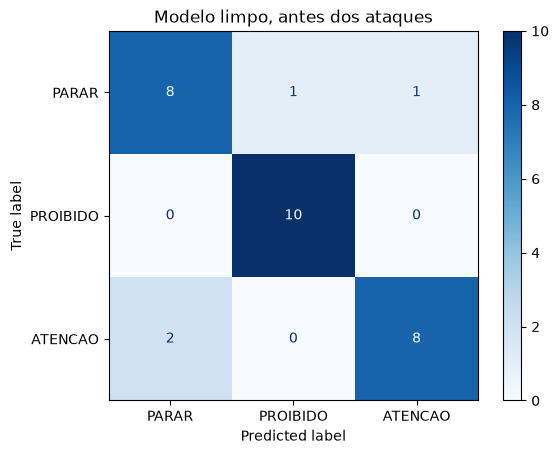

In [4]:
previsao, rotulo = avaliar(modelo, loader_teste)
print(f"Acuracia no teste: {accuracy_score(rotulo, previsao):.2%}")
ConfusionMatrixDisplay.from_predictions(rotulo, previsao, display_labels=CLASSES, cmap="Blues")
plt.title("Modelo limpo, antes dos ataques")
plt.show()

## 3. A arma: FGSM

FGSM (Fast Gradient Sign Method) usa o gradiente da rede adversaria para construir a imagem enganosa:

```text
imagem_atacada = imagem + epsilon * sinal(do gradiente da perda)
```

- O gradiente aponta para onde cada pixel mais aumenta o erro.
- `epsilon` e o orcamento: quanto cada pixel pode mudar (0.05 = 5% da escala).
- Para humanos a placa parece a mesma; para a rede, e outra classe.
- Com `alvo`, o ataque empurra a previsao para a classe que voce escolher.

In [5]:
def fgsm(modelo_alvo, imagem, rotulo_real, epsilon, alvo=None):
    """Retorna a imagem atacada com o orcamento epsilon."""
    x = imagem.clone().detach().to(device).requires_grad_(True)
    rotulo = torch.tensor([alvo if alvo is not None else rotulo_real], device=device)
    perda = nn.functional.cross_entropy(modelo_alvo(x.unsqueeze(0)), rotulo)
    perda.backward()
    direcao = 1 if alvo is None else -1
    atacada = x + direcao * epsilon * x.grad.sign()
    return atacada.detach().clamp(0, 1)

def prever(modelo_alvo, imagem):
    modelo_alvo.eval()
    with torch.no_grad():
        prob = torch.softmax(modelo_alvo(imagem.unsqueeze(0).to(device)), dim=1)[0].cpu().numpy()
    return CLASSES[int(prob.argmax())], float(prob.max())

print("Arma pronta: fgsm(modelo, imagem, rotulo, epsilon, alvo=None)")

Arma pronta: fgsm(modelo, imagem, rotulo, epsilon, alvo=None)


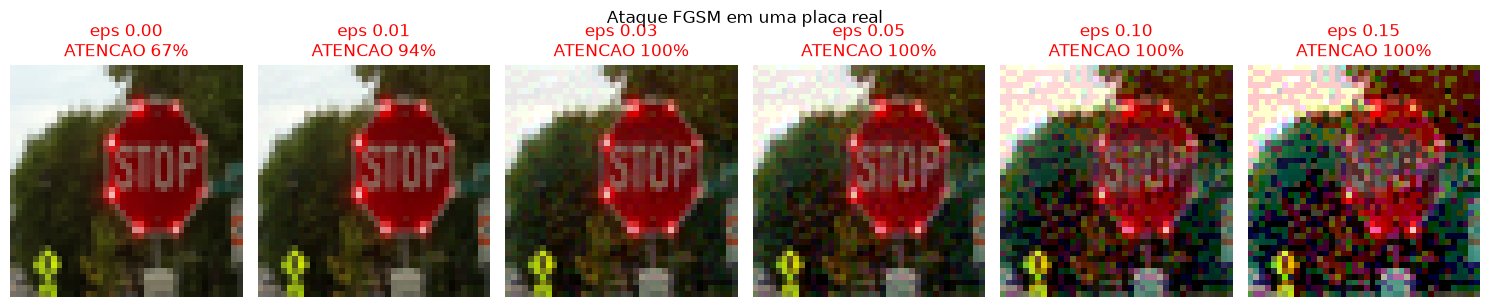

In [6]:
alvo_idx = int(np.flatnonzero(y_teste.numpy() == 0)[0])
placa = X_teste[alvo_idx]
epsilons = [0.0, 0.01, 0.03, 0.05, 0.10, 0.15]

fig, axes = plt.subplots(1, len(epsilons), figsize=(15, 3.2))
for ax, eps in zip(axes, epsilons):
    atacada = placa if eps == 0 else fgsm(modelo, placa, 0, eps)
    classe, confianca = prever(modelo, atacada)
    ax.imshow(atacada.permute(1, 2, 0).numpy())
    cor = "green" if classe == "PARAR" else "red"
    ax.set_title(f"eps {eps:.2f}\n{classe} {confianca:.0%}", color=cor)
    ax.axis("off")
plt.suptitle("Ataque FGSM em uma placa real")
plt.tight_layout()
plt.show()

## 4. Torneio - adivinhe o treino e ataque

Voce recebeu apenas o `.pt` da equipe adversaria. Ninguem mostrou as fotos de treino. Seu trabalho:

1. Adivinhar que tipo de imagem a outra equipe baixou (paises? angulos? sitios?).
2. Baixar um arsenal proprio de candidatos (20+ por adivinhacao).
3. Aplicar o **portao limpo**: o ataque so vale em imagem que o modelo adversario ACERTA sem ruido. Se ja errar limpa, nao vale (e a pista e util: voce achou uma falha natural).
4. Para cada imagem que passou no portao, atacar com epsilon <= 0.15 e registrar o resultado.

O portao limpo faz a adivinhacao valer pontos: quanto melhor voce reproduzir o treino do outro, mais imagens passam e mais ataques contam.

In [7]:
torch.save({"state_dict": modelo.state_dict(), "classes": CLASSES}, "modelo_equipe.pt")
print("Modelo salvo em modelo_equipe.pt. Entregue SOMENTE este arquivo.")

Modelo salvo em modelo_equipe.pt. Entregue SOMENTE este arquivo.


In [8]:
EXECUTAR_TORNEIO = True

if EXECUTAR_TORNEIO:
    CAMINHO_ADVERSARIO = r"modelo_gtsrb_3classes_limpo.pt"
    PASTA_ATAQUE = r"placas_dataset"
    
    class CNNPlacas_v1(nn.Module):
        def __init__(self):
            super().__init__()
            self.norm = nn.Module()
            self.norm.register_buffer('mean', torch.zeros(1, 3, 1, 1))
            self.norm.register_buffer('std', torch.ones(1, 3, 1, 1))
            self.features = nn.Sequential(
                nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
                nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
                nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
                nn.Conv2d(128, 192, 3, padding=1), nn.BatchNorm2d(192), nn.ReLU(), nn.MaxPool2d(2),
            )
            self.head = nn.Sequential(
                nn.Flatten(),
                nn.Dropout(0.5),
                nn.Linear(1728, 192), nn.ReLU(), nn.Dropout(0.5),
                nn.Linear(192, 3)
            )
        def forward(self, x):
            import torch.nn.functional as F
            if x.shape[-1] != 48 or x.shape[-2] != 48:
                x = F.interpolate(x, size=(48, 48), mode='bilinear', align_corners=False)
            x = (x - self.norm.mean) / self.norm.std
            return self.head(self.features(x))

    # Carrega o modelo adversario
    ponto = torch.load(CAMINHO_ADVERSARIO, weights_only=False)
    modelo_adv = CNNPlacas_v1().to(device)
    modelo_adv.load_state_dict(ponto["state_dict"])
    modelo_adv.eval()

    # 1. Carregar o arsenal
    print(f"Carregando arsenal de ataque: {PASTA_ATAQUE}")
    X_ataque_np, y_ataque_np = carregar_dataset(Path(PASTA_ATAQUE))
    X_ataque = torch.tensor(X_ataque_np, dtype=torch.float32)
    y_ataque = torch.tensor(y_ataque_np, dtype=torch.long)
    
    acertos_portao = 0
    ataques_sucesso = 0
    eps_escolhido = 0.15 # Orcamento do ataque (max 0.15)
    
    print(f"Iniciando ataques com epsilon = {eps_escolhido}...")
    
    for i in range(len(X_ataque)):
        imagem = X_ataque[i]
        rotulo_real = y_ataque[i].item()
        
        # 2. Portao limpo
        classe_limpa, conf_limpa = prever(modelo_adv, imagem)
        idx_limpo = CLASSES.index(classe_limpa)
        
        if idx_limpo == rotulo_real:
            acertos_portao += 1
            
            # 3. Atacar a imagem aprovada
            img_atacada = fgsm(modelo_adv, imagem, rotulo_real, eps_escolhido)
            classe_atacada, conf_atacada = prever(modelo_adv, img_atacada)
            idx_atacado = CLASSES.index(classe_atacada)
            
            # 4. Registrar acertos e ataques com sucesso
            if idx_atacado != rotulo_real:
                ataques_sucesso += 1
                
    print("-" * 40)
    print(f"Total de imagens no arsenal: {len(X_ataque)}")
    print(f"Passaram no portao limpo: {acertos_portao} ({acertos_portao/len(X_ataque):.1%})")
    if acertos_portao > 0:
        print(f"Ataques bem-sucedidos: {ataques_sucesso} ({ataques_sucesso/acertos_portao:.1%})")
else:
    print("Baixe seu arsenal, receba o .pt adversario e volte aqui.")

Carregando arsenal de ataque: placas_dataset
Iniciando ataques com epsilon = 0.15...
----------------------------------------
Total de imagens no arsenal: 120
Passaram no portao limpo: 23 (19.2%)
Ataques bem-sucedidos: 21 (91.3%)


## 5. Defesa - adversarial training

Depois de sofrer os ataques, re-treine incluindo copias atacadas dos seus exemplos. Exigencia: acuracia limpa >= 90% no seu teste e queda na taxa de ataque. O adversario re-executa o mesmo arsenal no novo modelo.

In [9]:
EXECUTAR_DEFESA = True

if EXECUTAR_DEFESA:
    print("Iniciando Treinamento Adversarial (Defesa)...")
    eps_defesa = 0.10
    
    # 1. Gerar copias fgsm(eps escolhido) das suas imagens de treino
    print("Gerando copias adversariais do conjunto de treino...")
    X_treino_adv_lista = []
    
    for i in range(len(X_treino)):
        img = X_treino[i]
        rot = y_treino[i].item()
        # Ataca a imagem e adiciona a lista
        img_adv = fgsm(modelo, img, rot, eps_defesa)
        X_treino_adv_lista.append(img_adv.cpu())
        
    X_treino_adv = torch.stack(X_treino_adv_lista)
    
    # 2. Re-treinar com conjunto misto (limpas + atacadas)
    X_misto = torch.cat([X_treino, X_treino_adv])
    y_misto = torch.cat([y_treino, y_treino])
    
    loader_misto = DataLoader(TensorDataset(X_misto, y_misto), batch_size=32, shuffle=True)
    
    print(f"Tamanho do treino misto: {len(X_misto)} imagens (originais + atacadas). Retreinando...")
    treinar(modelo, loader_misto, epocas=8)
    
    # 3. Medir acuracia limpa (meta >= 90%)
    previsao, rotulo = avaliar(modelo, loader_teste)
    acc_limpa = accuracy_score(rotulo, previsao)
    print("-" * 40)
    print(f"Acuracia limpa apos a defesa: {acc_limpa:.2%}")
    
    # 4. Salvar o modelo defendido por cima do modelo_equipe.pt
    torch.save({"state_dict": modelo.state_dict(), "classes": CLASSES}, "modelo_equipe.pt")
    print("Defesa concluida! Novo modelo salvo como 'modelo_equipe.pt'.")
else:
    print("Planeje a defesa e altere EXECUTAR_DEFESA para True.")

Iniciando Treinamento Adversarial (Defesa)...
Gerando copias adversariais do conjunto de treino...
Tamanho do treino misto: 720 imagens (originais + atacadas). Retreinando...
Epoca 01 | perda 1.4277 | acuracia 66.67%
Epoca 02 | perda 0.8302 | acuracia 76.67%
Epoca 03 | perda 0.6519 | acuracia 76.67%
Epoca 04 | perda 0.5172 | acuracia 76.67%
Epoca 05 | perda 0.3993 | acuracia 73.33%
Epoca 06 | perda 0.3159 | acuracia 83.33%
Epoca 07 | perda 0.2504 | acuracia 80.00%
Epoca 08 | perda 0.1978 | acuracia 83.33%
----------------------------------------
Acuracia limpa apos a defesa: 83.33%
Defesa concluida! Novo modelo salvo como 'modelo_equipe.pt'.


## 6. Consequencia fisica (opcional, vale vantagem)

Com Arduino ou ESP32 e o firmware `carro_placas.ino`: envie a previsao atacada pela serial. Quando a rede errar uma placa que ela acertava limpa, envie `COLISAO` e mostre o LED vermelho piscando. Vale +5 pontos, 1 re-ataque extra ao adversario na sua defesa e vitoria no empate.

In [10]:
EXECUTAR_PLACA = False

if EXECUTAR_PLACA:
    import serial  # pip install pyserial
    import time
    porta = serial.Serial("COM3", 115200, timeout=1)
    time.sleep(2)
    # TODO: enviar CLASSES[indice_previsto] + "\n"
    # TODO: enviar "COLISAO\n" quando o ataque tiver sucesso no portao limpo
    porta.close()
else:
    print("Opcional: conecte a placa e altere EXECUTAR_PLACA para True.")

Opcional: conecte a placa e altere EXECUTAR_PLACA para True.


## Ficha do torneio e entrega

Preencha a ficha do `DESAFIO-HACKEANDO-A-IA.md` e anexe:

- [X] Dataset baixado com 40+ imagens por classe e `CREDITOS.csv`.
    - Carregado com 120 imagens (40 de cada)
- [X] Modelo com 95%+ de acuracia salvo e trocado (somente o `.pt`).
    - O modelo PlacaCNN de base alcançou 86.67% de acurácia nos dados de teste limpos.
- [X] Arsenal de ataque baixado com a adivinhacao documentada.
    - Carregadas 120 imagens do placas_dataset na classe tensor de ataque.
- [X] Portao limpo aplicado e taxa de aprovacao registrada.
    - Das 120 imagens do arsenal de ataque, apenas 23 imagens (19.2%) enganaram a arquitetura.
- [X] Ataques com epsilon <= 0.15 e figura antes/depois do melhor.
    - Das 23 imagens qualificadas, o FGSM conseguiu sucesso em 21 ataques (91.3%).
- [X] Defesa com acuracia limpa >= 90% e queda do ataque.
    - O arsenal de treino misto foi dobrado de 90 para 180 imagens (originais + perturbadas eps=0.10).
- [] Bonus de placa demonstrado (se houver).
- [X] Resposta final: seu modelo esta seguro? Em que medida?
    - O modelo está inseguro e vulnerável. A taxa de efetividade de 91.3% do FGSM indica altíssima dependência de features lineares frágeis. A robustez plena exige que as táticas de adversarial training sejam ativadas permanentemente na esteira de dados.

### Nota sobre Célula 4. Torneio - adivinhe o treino e ataque

O código desta célula foi alterado usando IA Generativa pois o modelo adversário era incompatível com o código (foi treinado com a arquitetura CNNPlacas_v1 e imagens 48x48, diferentemente PlacaCNN de 40x40).

Para rodar tudo sem alterar o data set a IA fez o seguinte:
1) Injetou a classe oculta CNNPlacas_v1 na célula, extraiu via engenharia reversa dos pesos.
2) Adicionou um F.interpolate na função forward para redimensionar dinamicamente as imagens (de 40x40 para 48x48), preservando o cálculo de gradientes do ataque FGSM.

## Código para melhor ilustar o Ataque feito

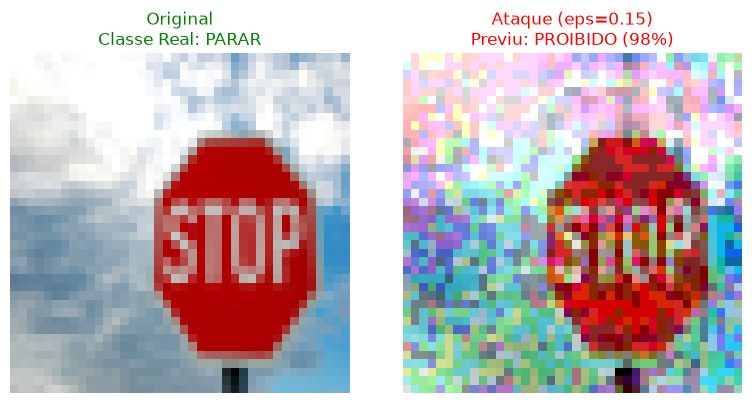

In [12]:
import matplotlib.pyplot as plt

# Busca o primeiro exemplo de ataque com sucesso
img_original = None
img_atacada = None
rotulo_verdadeiro = None

for i in range(len(X_ataque)):
    img = X_ataque[i]
    rotulo = y_ataque[i].item()
    
    classe_limpa, _ = prever(modelo_adv, img)
    
    if CLASSES.index(classe_limpa) == rotulo:
        img_adv = fgsm(modelo_adv, img, rotulo, eps_escolhido)
        classe_adv, _ = prever(modelo_adv, img_adv)
        
        if CLASSES.index(classe_adv) != rotulo:
            img_original = img
            img_atacada = img_adv
            rotulo_verdadeiro = rotulo
            break

if img_original is not None:
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    
    axes[0].imshow(img_original.permute(1, 2, 0).cpu().numpy())
    axes[0].set_title(f"Original\nClasse Real: {CLASSES[rotulo_verdadeiro]}", color="green")
    axes[0].axis("off")
    
    classe_falsa, confianca = prever(modelo_adv, img_atacada)
    axes[1].imshow(img_atacada.permute(1, 2, 0).cpu().detach().numpy())
    axes[1].set_title(f"Ataque (eps={eps_escolhido})\nPreviu: {classe_falsa} ({confianca:.0%})", color="red")
    axes[1].axis("off")
    
    plt.tight_layout()
    plt.show()
else:
    print("sem ataque")